# Análisis Cluster con KMeans

### Docente: Dr. Richard Fernández

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.metrics import silhouette_samples, silhouette_score
import random as rd

In [ ]:
data = pd.read_csv("customer.csv", sep=',')

In [ ]:
# Descripción de variables numéricas:
# V1: CustomerLifetimeValue (Valor del cliente).
# V2: Income (Ingreso del cliente).
# V3: MonthlyPremiumAuto (Prima mensual del seguro).
# V4: ClaimAmount (Monto de las reclamaciones).

In [ ]:
data.head()

,Unnamed: 0,Customer,State,CustomerLifetimeValue,Response,Coverage,Education,EffectiveToDate,EmploymentStatus,Gender,...,MonthsSincePolicyInception,NumberofOpenComplaints,NumberofPolicies,PolicyType,Policy,RenewOfferType,SalesChannel,ClaimAmount,VehicleClass,VehicleSize
0,0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  9134 non-null   int64  
 1   Customer                    9134 non-null   object 
 2   State                       9134 non-null   object 
 3   CustomerLifetimeValue       9134 non-null   float64
 4   Response                    9134 non-null   object 
 5   Coverage                    9134 non-null   object 
 6   Education                   9134 non-null   object 
 7   EffectiveToDate             9134 non-null   object 
 8   EmploymentStatus            9134 non-null   object 
 9   Gender                      9134 non-null   object 
 10  Income                      9134 non-null   int64  
 11  LocationCode                9134 non-null   object 
 12  MaritalStatus               9134 non-null   object 
 13  MonthlyPremiumAuto          9134 

In [ ]:
# Seleccionar las variables para K-Means
data_X = data[
    [
        "CustomerLifetimeValue",
        "Income",
        "MonthlyPremiumAuto",
        "ClaimAmount"
    ]
]

# Cambiar el nombre de las columnas
data_X.columns = ["V1", "V2", "V3", "V4"]

In [ ]:
data_X.head()

,V1,V2,V3,V4
0,2763.519279,56274,69,384.811147
1,6979.535903,0,94,1131.464935
2,12887.431650,48767,108,566.472247
3,7645.861827,0,106,529.881344
4,2813.692575,43836,73,138.130879


In [ ]:
data_X.dtypes

,0
V1,float64
V2,int64
V3,int64
V4,float64


In [ ]:
data_X.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0


In [ ]:
data_X.count()

,0
V1,9134
V2,9134
V3,9134
V4,9134


In [ ]:
data_X.describe()

,V1,V2,V3,V4
count,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,434.088794
std,6870.967608,30379.904734,34.407967,290.500092
min,1898.007675,0.000000,61.000000,0.099007
25%,3994.251794,0.000000,68.000000,272.258244
50%,5780.182197,33889.500000,83.000000,383.945434
75%,8962.167041,62320.000000,109.000000,547.514839
max,83325.381190,99981.000000,298.000000,2893.239678


In [ ]:
data_X_scale = pd.DataFrame(StandardScaler().fit_transform(data_X))
data_X_scale.columns = ["V1","V2","V3","V4"]
data_X_scale.head()

,V1,V2,V3,V4
0,-0.762878,0.612827,-0.703925,-0.169640
1,-0.149245,-1.239617,0.022691,2.400737
2,0.710636,0.365710,0.429596,0.455734
3,-0.052263,-1.239617,0.371467,0.329769
4,-0.755575,0.203390,-0.587666,-1.018843


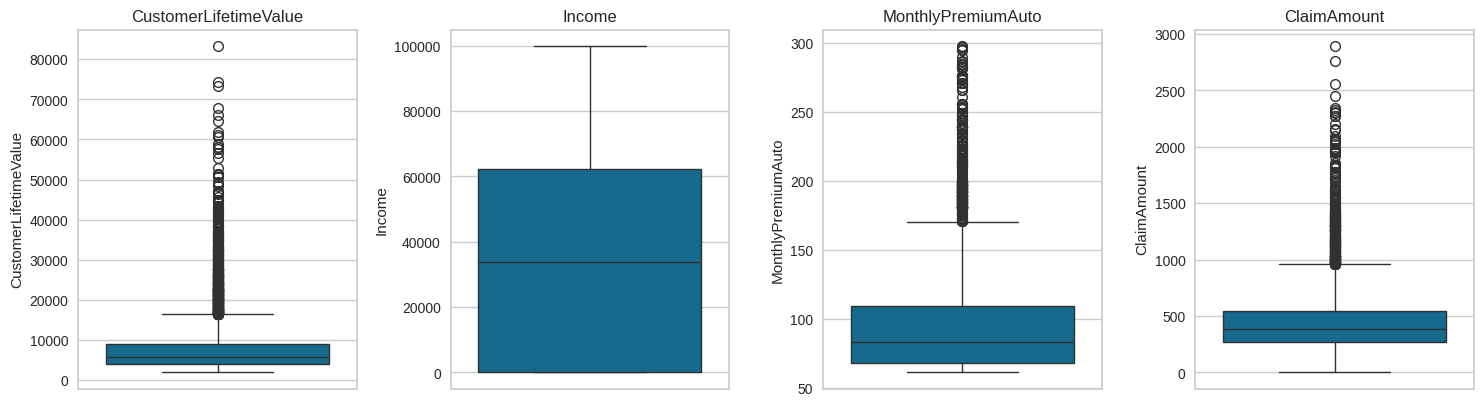

In [ ]:
variables = [
    "CustomerLifetimeValue",
    "Income",
    "MonthlyPremiumAuto",
    "ClaimAmount"
]

plt.figure(figsize=(15,8))

for i, var in enumerate(variables):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=data[var])
    plt.title(var)

plt.tight_layout()
plt.show()

In [ ]:
# Variables para guardar el mejor resultado
mejor_k = None
mejor_score = -1

# Evaluación de varios valores de k
for k in range(2, 11):

    # Aplicar K-Means
    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(data_X_scale)

    # Calcular Silhouette Score
    score = silhouette_score(data_X_scale, labels)

    # Interpretación del resultado
    if score >= 0.7:
        mensaje = "Excelente separación entre clusters."
    elif score >= 0.5:
        mensaje = "Buena calidad de agrupamiento."
    elif score >= 0.25:
        mensaje = "Agrupamiento aceptable, pero con cierta superposición."
    else:
        mensaje = "Los clusters presentan poca separación o pueden no ser adecuados."

    print(f"k={k:2d} -> Silhouette Score = {score:.4f} | {mensaje}")

    # Guardar el mejor resultado
    if score > mejor_score:
        mejor_score = score
        mejor_k = k

# Resultado final
print("\n" + "=" * 60)
print(f"MEJOR RESULTADO: k = {mejor_k}")
print(f"Coeficiente de Silhouette: {mejor_score:.4f}")
print("=" * 60)

k= 2 -> Silhouette Score = 0.3799 | Agrupamiento aceptable, pero con cierta superposición.
k= 3 -> Silhouette Score = 0.2993 | Agrupamiento aceptable, pero con cierta superposición.
k= 4 -> Silhouette Score = 0.3202 | Agrupamiento aceptable, pero con cierta superposición.
k= 5 -> Silhouette Score = 0.3047 | Agrupamiento aceptable, pero con cierta superposición.
k= 6 -> Silhouette Score = 0.2951 | Agrupamiento aceptable, pero con cierta superposición.
k= 7 -> Silhouette Score = 0.3008 | Agrupamiento aceptable, pero con cierta superposición.
k= 8 -> Silhouette Score = 0.2567 | Agrupamiento aceptable, pero con cierta superposición.
k= 9 -> Silhouette Score = 0.2587 | Agrupamiento aceptable, pero con cierta superposición.
k=10 -> Silhouette Score = 0.2582 | Agrupamiento aceptable, pero con cierta superposición.

MEJOR RESULTADO: k = 2
Coeficiente de Silhouette: 0.3799


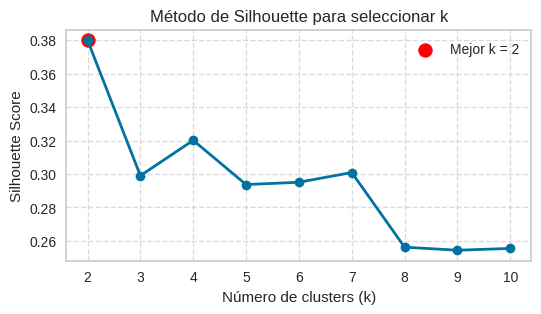

In [ ]:
# Calcular silhouette para distintos valores de k
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(data_X_scale)
    score = silhouette_score(data_X_scale, labels)
    silhouette_scores.append(score)

# Gráfico
plt.figure(figsize=(6, 3))
plt.plot(k_values, silhouette_scores, marker='o', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Método de Silhouette para seleccionar k')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltar el mejor k
best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)
plt.scatter(best_k, best_score, color='red', s=100,label=f'Mejor k = {best_k}')
plt.legend()
plt.show()

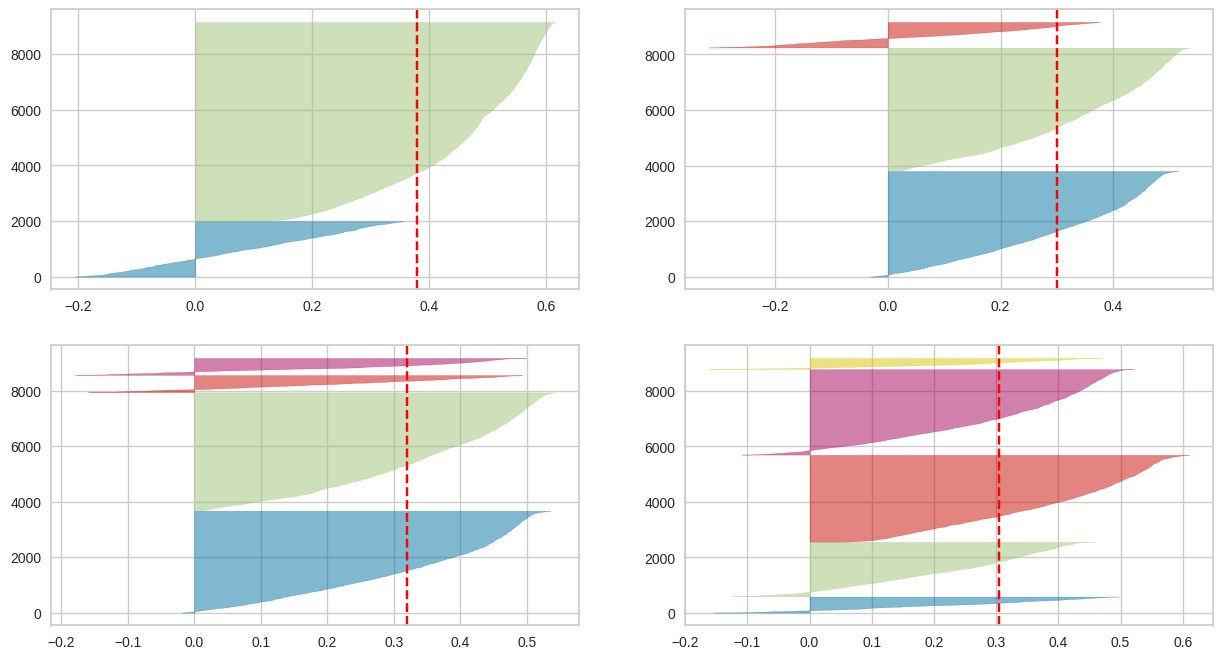

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15,8))
for i in [2, 3, 4, 5]:
    # Creación de una instancia de KMeans para un número diferente de clústeres
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)

    # Creación de una instancia de SilhouetteVisualizer con una instancia de KMeans
    # Ajuste del visualizador
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(data_X_scale)

### Modelo Kmeans

In [ ]:
#Se establece una semilla para obtener el mismo resultado
rd.seed(42)

In [ ]:
kmeans = KMeans(n_clusters = 2).fit(data_X_scale)

In [ ]:
labels = pd.DataFrame(kmeans.labels_)
labels.columns = ['Segmento']
labels.head()

,Segmento
0,0
1,1
2,1
3,0
4,0


In [ ]:
data_final = pd.concat([data_X,labels], axis = 1)

data_final_categoricas =  pd.concat([data,labels], axis = 1)
data_final_categoricas = data_final_categoricas[
    [
        "CustomerLifetimeValue",
        "Income",
        "MonthlyPremiumAuto",
        "ClaimAmount",
        "Coverage",
        "Education",
        "EmploymentStatus",
        "Gender",
        "MaritalStatus",
        "SalesChannel",
        "VehicleClass",
        "VehicleSize",
        "Segmento"
    ]
]


data_final.head()

,V1,V2,V3,V4,Segmento
0,2763.519279,56274,69,384.811147,0
1,6979.535903,0,94,1131.464935,1
2,12887.431650,48767,108,566.472247,1
3,7645.861827,0,106,529.881344,0
4,2813.692575,43836,73,138.130879,0


In [ ]:
data_final.groupby('Segmento').size().reset_index(name='cantidad')

,Segmento,cantidad
0,0,7149
1,1,1985


In [ ]:
data_final_categoricas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerLifetimeValue  9134 non-null   float64
 1   Income                 9134 non-null   int64  
 2   MonthlyPremiumAuto     9134 non-null   int64  
 3   ClaimAmount            9134 non-null   float64
 4   Coverage               9134 non-null   object 
 5   Education              9134 non-null   object 
 6   EmploymentStatus       9134 non-null   object 
 7   Gender                 9134 non-null   object 
 8   MaritalStatus          9134 non-null   object 
 9   SalesChannel           9134 non-null   object 
 10  VehicleClass           9134 non-null   object 
 11  VehicleSize            9134 non-null   object 
 12  Segmento               9134 non-null   int32  
dtypes: float64(2), int32(1), int64(2), object(8)
memory usage: 892.1+ KB


In [ ]:
data_final.to_csv('customer_segmentado.csv', index=False)

In [ ]:
data_final.head()

,V1,V2,V3,V4,Segmento
0,2763.519279,56274,69,384.811147,0
1,6979.535903,0,94,1131.464935,1
2,12887.431650,48767,108,566.472247,1
3,7645.861827,0,106,529.881344,0
4,2813.692575,43836,73,138.130879,0


### Perfilamiento de segmentos

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_X_scale)

df_pca = pd.DataFrame(X_pca, columns=["PC1","PC2"])
df_pca["Segmento"] = data_final["Segmento"]

In [ ]:
df_pca.head()

,PC1,PC2,Segmento
0,-1.005129,-0.002096,0
1,1.750054,-1.647067,1
2,0.755340,0.631405,1
3,0.713672,-1.017092,0
4,-1.360701,-0.095567,0


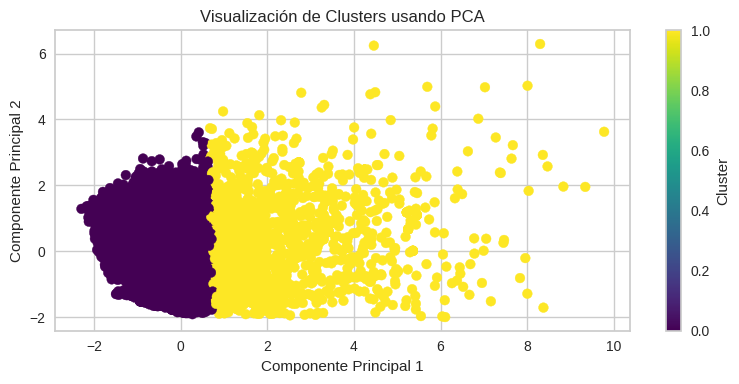

In [ ]:
plt.figure(figsize=(8,4))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["Segmento"],
    cmap="viridis"
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Visualización de Clusters usando PCA")

plt.colorbar(label="Cluster")

plt.tight_layout()
plt.show()

In [ ]:
data_final.groupby(['Segmento'])[['V1','V2','V3','V4']].agg(['mean'])

,V1,V2,V3,V4
,mean,mean,mean,mean
Segmento,,,,
0,6323.303123,41573.483564,81.262414,334.787592
1,14061.376458,23553.488665,136.282116,791.723200


In [ ]:
# Descripción de variables numéricas:
# V1: CustomerLifetimeValue (Valor del cliente).
# V2: Income (Ingreso del cliente).
# V3: MonthlyPremiumAuto (Prima mensual del seguro).
# V4: ClaimAmount (Monto de las reclamaciones).

#0 => V2 (Clientes conservadores)
#1 => V1, V2, V4 (Clientes de alto valor)


In [ ]:
sample_silhouette_values = silhouette_samples(data_X_scale, data_final['Segmento'])
sample_silhouette_values

array([ 0.58350061,  0.13458424, -0.19419944, ..., -0.08464678,
        0.19922269,  0.46130675])

In [ ]:
silhouette_df = pd.DataFrame({'silhouette': sample_silhouette_values
                              })
silhouette_df = pd.concat([data_final,silhouette_df], axis = 1)
silhouette_df.head()

,V1,V2,V3,V4,Segmento,silhouette
0,2763.519279,56274,69,384.811147,0,0.583501
1,6979.535903,0,94,1131.464935,1,0.134584
2,12887.431650,48767,108,566.472247,1,-0.194199
3,7645.861827,0,106,529.881344,0,0.177203
4,2813.692575,43836,73,138.130879,0,0.601658


In [ ]:
negativas = (silhouette_df["silhouette"] < 0).sum()
total = len(silhouette_df)

print(f"Siluetas negativas: {negativas}")
print(f"Porcentaje: {negativas/total*100:.2f}%")

Siluetas negativas: 651
Porcentaje: 7.13%


### Implementación

In [ ]:
#Exportar el modelo
import joblib

joblib.dump(kmeans, "modelo_kmeans.pkl")
print("Modelo guardado correctamente")

Modelo guardado correctamente


In [ ]:
#Importar el modelo
import joblib

modelo_cargado = joblib.load("modelo_kmeans.pkl")
print("Modelo cargado correctamente")

Modelo cargado correctamente


In [ ]:
modelo_cargado

KMeans(n_clusters=2)

### Perfilamiento con variables categóricas

In [ ]:
data_final_categoricas["Segmento"] = data_final_categoricas["Segmento"].replace({
    0: "Clientes conservadores",
    1: "Clientes de alto valor"
})
data_final_categoricas

,CustomerLifetimeValue,Income,MonthlyPremiumAuto,ClaimAmount,Coverage,Education,EmploymentStatus,Gender,MaritalStatus,SalesChannel,VehicleClass,VehicleSize,Segmento
0,2763.519279,56274,69,384.811147,Basic,Bachelor,Employed,F,Married,Agent,Two-Door Car,Medsize,Clientes conservadores
1,6979.535903,0,94,1131.464935,Extended,Bachelor,Unemployed,F,Single,Agent,Four-Door Car,Medsize,Clientes de alto valor
2,12887.431650,48767,108,566.472247,Premium,Bachelor,Employed,F,Married,Agent,Two-Door Car,Medsize,Clientes de alto valor
3,7645.861827,0,106,529.881344,Basic,Bachelor,Unemployed,M,Married,Call Center,SUV,Medsize,Clientes conservadores
4,2813.692575,43836,73,138.130879,Basic,Bachelor,Employed,M,Single,Agent,Four-Door Car,Medsize,Clientes conservadores
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,23405.987980,71941,73,198.234764,Basic,Bachelor,Employed,M,Married,Web,Four-Door Car,Medsize,Clientes conservadores
9130,3096.511217,21604,79,379.200000,Extended,College,Employed,F,Divorced,Branch,Four-Door Car,Medsize,Clientes conservadores
9131,8163.890428,0,85,790.784983,Extended,Bachelor,Unemployed,M,Single,Branch,Four-Door Car,Medsize,Clientes de alto valor
9132,7524.442436,21941,96,691.200000,Extended,College,Employed,M,Married,Branch,Four-Door Car,Large,Clientes conservadores


In [ ]:
# Descripción de variables categóricas:
# Coverage: Tipo o nivel de cobertura del seguro.
# EmploymentStatus: Estado laboral del cliente.
# Gender: Género del cliente.
# MaritalStatus: Estado civil del cliente.
# SalesChannel: Canal de venta por el cual se adquirió el seguro.
# VehicleClass: Clase o tipo de vehículo del cliente.

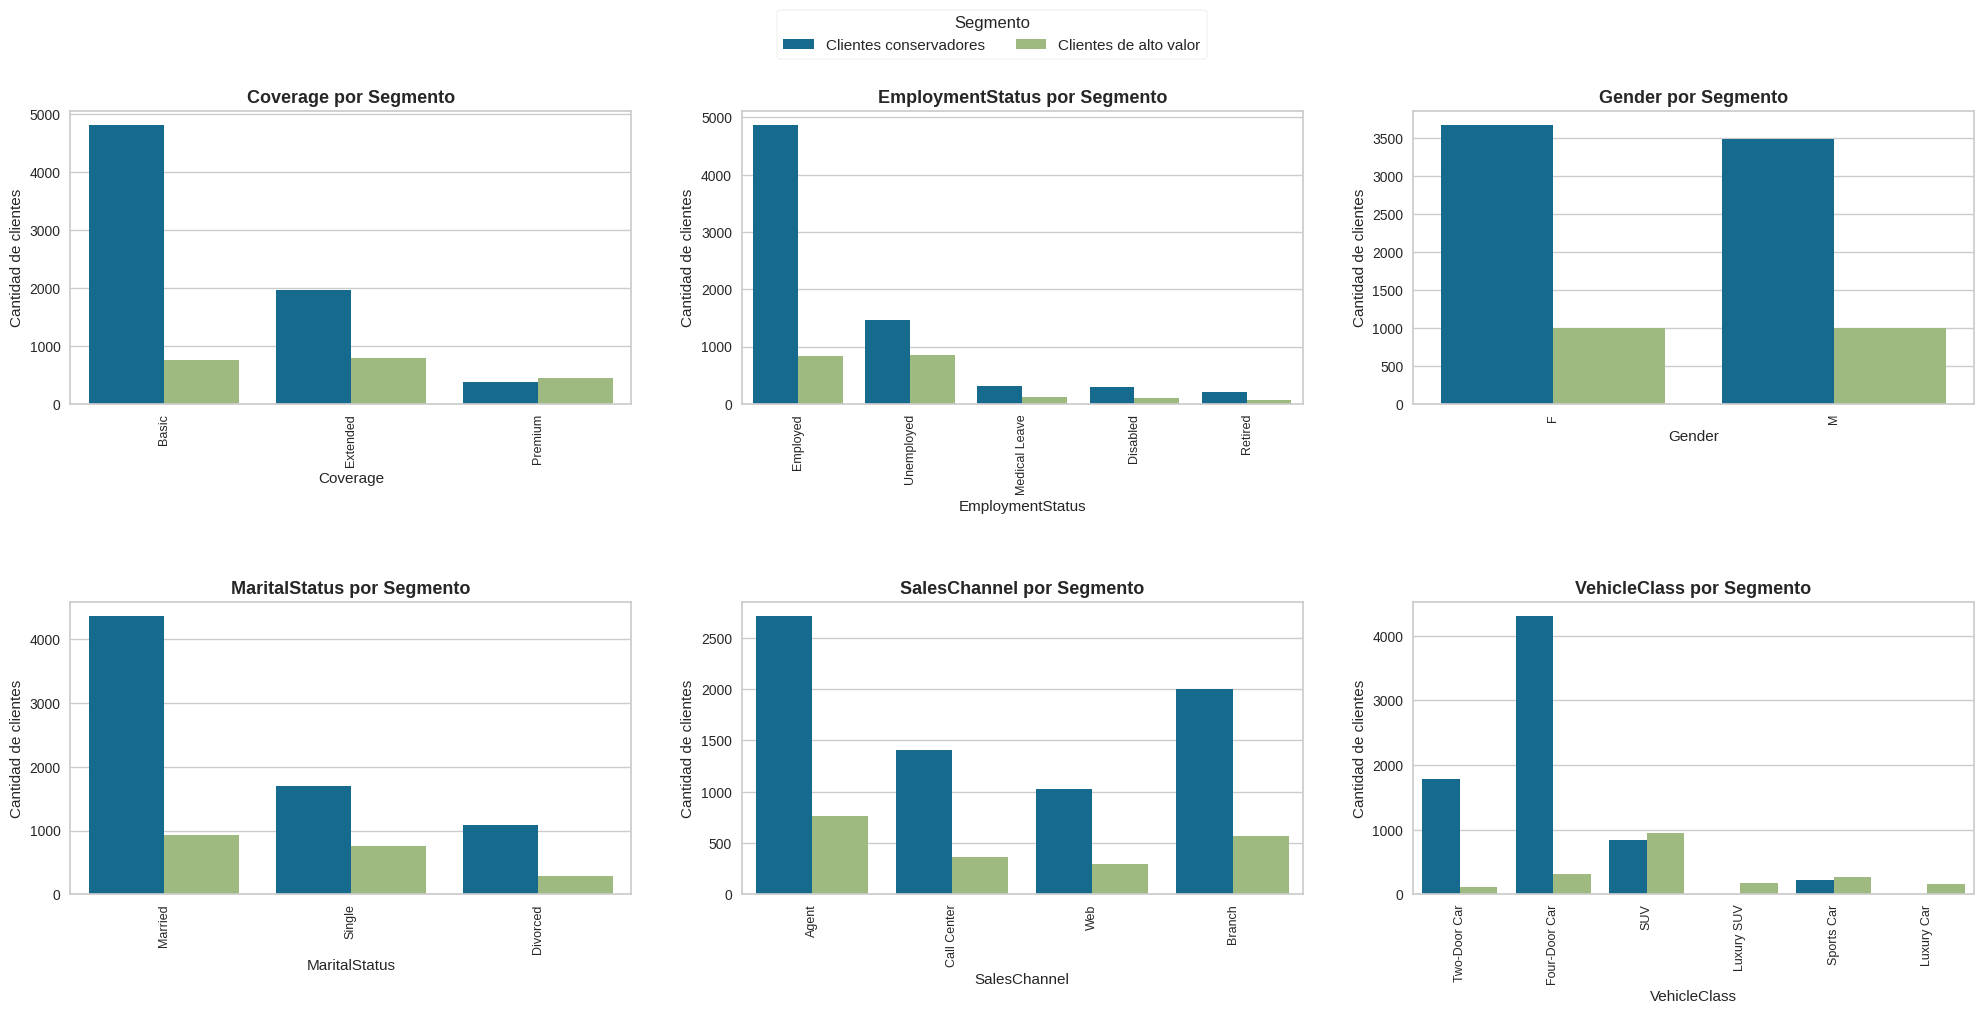

In [ ]:
variables_categoricas = [
    "Coverage",
    "EmploymentStatus",
    "Gender",
    "MaritalStatus",
    "SalesChannel",
    "VehicleClass"
]

# 4 columnas x 2 filas
fig, ax = plt.subplots(2, 3, figsize=(20, 10))
ax = ax.flatten()

for i, variable in enumerate(variables_categoricas):

    sns.countplot(
        data=data_final_categoricas,
        x=variable,
        hue="Segmento",
        ax=ax[i]
    )

    ax[i].set_title(
        f"{variable} por Segmento",
        fontsize=13,
        fontweight="bold"
    )

    ax[i].set_xlabel(variable, fontsize=11)
    ax[i].set_ylabel("Cantidad de clientes", fontsize=11)

    ax[i].tick_params(
        axis="x",
        labelrotation=90,
        labelsize=9
    )

    # Eliminar leyenda individual
    if ax[i].get_legend() is not None:
        ax[i].get_legend().remove()

# Crear una sola leyenda general
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Segmento",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95],
    h_pad=4,
    w_pad=3
)

# Guardar
ruta = "/content/Subplots_Perfilamiento_Segmentos.png"

plt.savefig(
    ruta,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Segmento,Clientes conservadores,Clientes de alto valor
Clientes,7149,1985
% Clientes,78.3%,21.7%
CustomerLifetimeValue,"6,323.30","14,061.38"
Income,"41,573.48","23,553.49"
MonthlyPremiumAuto,81.26,136.28
ClaimAmount,334.79,791.72
Coverage,Basic (67.2%),Extended (39.4%)
EmploymentStatus,Employed (68.0%),Unemployed (42.7%)
Gender,F (51.3%),F (50.0%)
MaritalStatus,Married (61.1%),Married (47.0%)


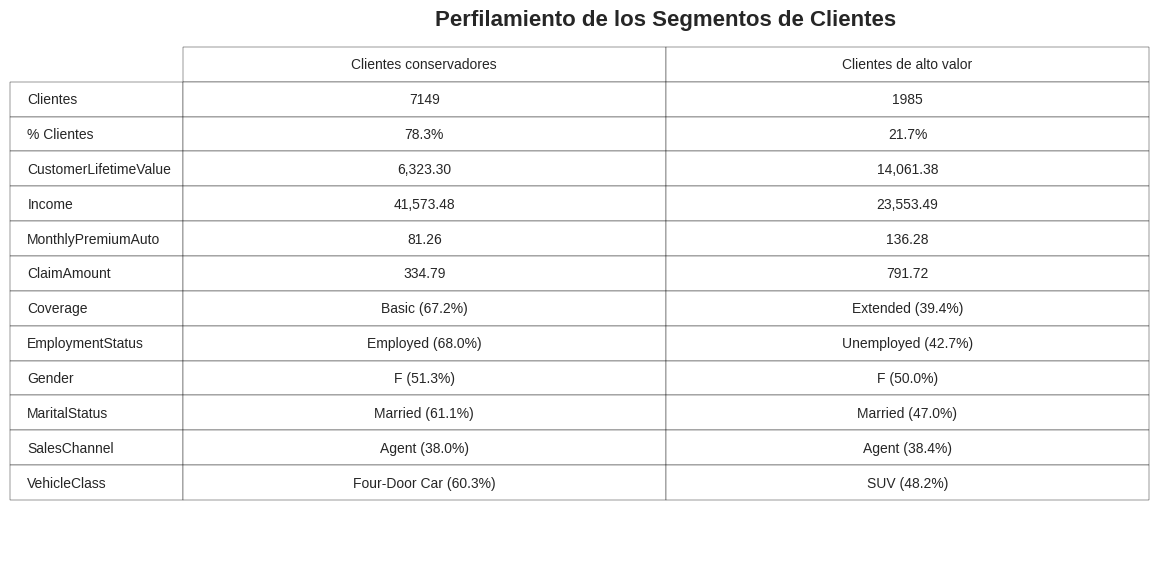

In [ ]:
variables_numericas = [
    "CustomerLifetimeValue",
    "Income",
    "MonthlyPremiumAuto",
    "ClaimAmount"
]

variables_categoricas = [
    "Coverage",
    "EmploymentStatus",
    "Gender",
    "MaritalStatus",
    "SalesChannel",
    "VehicleClass",
]

# Crear resumen
resumen = []

for segmento in data_final_categoricas["Segmento"].unique():

    df_seg = data_final_categoricas[
        data_final_categoricas["Segmento"] == segmento
    ]

    fila = {
        "Segmento": segmento,
        "Clientes": len(df_seg),
        "% Clientes": f"{len(df_seg)/len(data_final_categoricas)*100:.1f}%"
    }

    # Promedios numéricos
    for var in variables_numericas:
        fila[var] = f"{df_seg[var].mean():,.2f}"

    # Categorías dominantes
    for var in variables_categoricas:
        dominante = df_seg[var].mode()[0]
        porcentaje = df_seg[var].value_counts(normalize=True).iloc[0] * 100
        fila[var] = f"{dominante} ({porcentaje:.1f}%)"

    resumen.append(fila)

# Convertir en DataFrame
resumen_df = pd.DataFrame(resumen).set_index("Segmento").T

# Mostrar tabla
display(resumen_df)

# Crear imagen
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

tabla = ax.table(
    cellText=resumen_df.values,
    rowLabels=resumen_df.index,
    colLabels=resumen_df.columns,
    cellLoc="center",
    loc="upper center"
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.8)

plt.title(
    "Perfilamiento de los Segmentos de Clientes",
    fontsize=16,
    fontweight="bold",
    pad=8
)

plt.tight_layout()

# Guardar imagen
plt.savefig(
    "/content/Cuadro_Perfilamiento_Segmentos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()